# ALLOW 시나리오 3종(BOOKING / DETAIL / CAPTCHA) 비교 EDA

`data_0514_1800_v1` 의 세 시나리오(`booking/allow`, `detail/allow`, `captcha/allow`) 데이터를 비교 분석합니다.
세 시나리오 모두 라벨은 `ALLOW` 이며, **휴먼의 마우스 행동이 시나리오에 따라 어떻게 다른가** 를 확인하는 것이 분석 의도입니다.

## 노트북 흐름

1. 데이터 준비 — 세 디렉토리 로드 + type 컬럼 부여
2. 전처리 — 사용 가능한 feature 선별 + 결측률 점검
3. 기본 분석 — Pairwise SMD 3쌍 (BOOKING↔DETAIL, BOOKING↔CAPTCHA, DETAIL↔CAPTCHA)
    - 3-1. 분포 시각화 (boxplot, top feature)
    - 3-2. 시나리오별 상관관계
    - 3-3. PCA 산점도
4. 결과 해석 가이드

## 비교 메트릭: SMD (Standardized Mean Difference)

두 그룹의 평균 차이를 합동 표준편차(pooled std)로 나눈 표준화 효과크기입니다. 단위에 무관하게 그룹 간 차이의 크기를 가늠할 수 있습니다.

| `|SMD|` 범위 | 해석 |
| --- | --- |
| `< 0.2` | 거의 차이 없음 (negligible) |
| `0.2 ~ 0.5` | 작은 차이 (small) |
| `0.5 ~ 0.8` | 중간 차이 (medium) |
| `0.8 ~ 1.5` | 큰 차이 (large) |
| `1.5 ~ 3.0` | 매우 큰 차이 (very_large) |
| `≥ 3.0` | 극단적 차이 (huge) |

### 환경 셋업

라이브러리 import + pandas 출력 옵션 + 한글 폰트(Malgun Gothic on Windows) 적용. **다른 셀을 실행하기 전에 반드시 이 셀을 먼저 실행**해야 합니다.

In [7]:
import os
from itertools import combinations
from pathlib import Path
import json
import platform

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yaml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.unicode_minus"] = False

# 한글 폰트 적용 (OS 별)
system = platform.system()
if system == "Darwin":
    font_candidates = ["AppleGothic", "Nanum Gothic"]
elif system == "Windows":
    font_candidates = ["Malgun Gothic"]
else:
    font_candidates = ["Nanum Gothic", "DejaVu Sans"]
for _font in font_candidates:
    try:
        plt.rcParams["font.family"] = _font
        print(f"한글 폰트 적용: {_font}")
        break
    except Exception:
        continue

# seaborn theme 가 font.family 를 덮어쓸 수 있어 한 번 더 적용
sns.set_theme(style="whitegrid", context="talk", font=plt.rcParams["font.family"][0])


# ---- 경로 자동 탐색 (jupyter cwd 와 무관하게 작동) ----
# Path.cwd() 부터 위로 올라가면서 services/ai/train/EDA 폴더를 찾아
# EDA_ROOT 로 정의. 이후 모든 셀에서 EDA_ROOT 기반 절대 경로 사용.
def _find_eda_root() -> Path:
    cur = Path.cwd().resolve()
    for parent in [cur] + list(cur.parents):
        candidate = parent / "services" / "ai" / "train" / "EDA"
        if candidate.exists():
            return candidate
    # cwd 자체가 EDA 폴더거나 그 하위인 경우
    for parent in [cur] + list(cur.parents):
        if parent.name == "EDA" and (parent / "trial_loader.py").exists():
            return parent
    raise FileNotFoundError(
        f"services/ai/train/EDA 폴더를 못 찾음. cwd={cur}. "
        f"리포 안에서 jupyter 를 실행했는지 확인하세요."
    )

EDA_ROOT = _find_eda_root()
AI_ROOT = EDA_ROOT.parent.parent  # services/ai
print(f"EDA_ROOT: {EDA_ROOT}")
print(f"AI_ROOT:  {AI_ROOT}")


한글 폰트 적용: Malgun Gothic
EDA_ROOT: C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\EDA
AI_ROOT:  C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai


## 1. 데이터 준비

### 1-1. 세 시나리오 trial 적재

세 시나리오 디렉토리(`booking/allow`, `detail/allow`, `captcha/allow`)의 `trial_*.json` 들을 모두 적재해서 long-form DataFrame `raw_df` 를 만듭니다.

**데이터 구조**
- 한 행 = 한 trial (마우스 행동 한 세션)
- `dataset` / `type` 컬럼: 시나리오 표시 (BOOKING / DETAIL / CAPTCHA)
- `trial_id`, `label` (모두 `ALLOW`), `source_file`: 식별자
- 나머지 컬럼: trial 의 `metrics` (38개 마우스 행동 feature) 가 펼쳐진 형태

`raw_df.head()` 로 컬럼 구조와 첫 5행의 값을 확인합니다. 결측(NaN)이 많은 컬럼이 보이면 ALLOW 데이터에서 채워지지 않는 feature 입니다.

In [8]:
# 시나리오별 디렉토리 정의 (EDA_ROOT 기반 절대 경로)
BASE_DIR = AI_ROOT / "data" / "data_0514_1800_v1"

DATASETS = {
    "BOOKING": BASE_DIR / "booking" / "allow",
    "DETAIL":  BASE_DIR / "detail"  / "allow",
    "CAPTCHA": BASE_DIR / "captcha" / "allow",
}
ID_COLS = ["dataset", "type", "trial_id", "label", "source_file"]
TYPE_PALETTE = {"BOOKING": "#1f77b4", "DETAIL": "#2ca02c", "CAPTCHA": "#d62728"}

# 디렉토리 존재 검증 (silent 실패 방지)
for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(f"데이터 디렉토리 없음: {name} -> {path}")
    n_files = len(list(path.glob("trial_*.json")))
    print(f"  {name}: {path} ({n_files} files)")


def load_allow_dataset(dataset_name: str, data_dir: Path) -> pd.DataFrame:
    """단일 시나리오 디렉토리의 trial_*.json 들을 DataFrame 으로 적재."""
    rows = []
    for path in sorted(data_dir.glob("trial_*.json")):
        raw = json.loads(path.read_text(encoding="utf-8"))
        row = {
            "dataset": dataset_name,
            "type": raw.get("type", dataset_name),
            "trial_id": raw.get("trialId"),
            "label": raw.get("label"),
            "source_file": path.name,
        }
        row.update(raw.get("metrics", {}))
        rows.append(row)
    return pd.DataFrame(rows)


frames = [load_allow_dataset(name, path) for name, path in DATASETS.items()]
raw_df = pd.concat(frames, ignore_index=True)

print(f"\n전체 trial 개수: {len(raw_df)}")
raw_df.head()


  BOOKING: C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_0514_1800_v1\booking\allow (253 files)
  DETAIL: C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_0514_1800_v1\detail\allow (252 files)
  CAPTCHA: C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_0514_1800_v1\captcha\allow (241 files)

전체 trial 개수: 746


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_28008\2881574986.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  raw_df = pd.concat(frames, ignore_index=True)


,dataset,type,trial_id,label,source_file,reclick_rate,misclick_rate,mouse_jerk_mean,double_click_rate,mouse_overshoot_flag,mousemove_event_rate,pre_click_scroll_flag,time_to_first_click_ms,inter_click_interval_ms,mouse_acceleration_mean,mouse_speed_change_mean,pre_click_hover_time_ms,click_offset_variance_px,mouse_stop_segment_count,mouse_avg_speed_px_per_ms,mouse_hover_dwell_time_ms,mouse_max_speed_px_per_ms,mouse_path_curvature_mean,pre_click_mousemove_count,click_position_repeat_rate,mouse_direction_change_count,mouse_path_straightness_score,edge_or_fixed_point_visit_rate,mouse_total_travel_distance_px,click_sequence_consistency_score,immediate_post_render_click_rate,pre_click_path_300ms_straightness,pre_click_path_500ms_straightness,inter_element_move_interval_std_ms,click_offset_from_element_center_px,time_from_element_visible_to_click_ms,pre_click_path_300ms_total_distance_px,pre_click_path_500ms_total_distance_px,time_from_element_clickable_to_click_ms
0,BOOKING,BOOKING,3,ALLOW,trial_00003.json,0,0,0.0002,0.1250,0,8.8760,0.0000,2488,"1,076.8571",0.0094,0.5293,145.5000,None,10.0000,0.3156,NaN,5.2751,0.0669,5.5000,0.0000,22.0000,0.2056,0.0225,"3,164.8582",0.0000,NaN,0.9900,0.9900,None,None,None,32,64,None
1,BOOKING,BOOKING,6,ALLOW,trial_00006.json,0,0,0.0002,0.0000,0,4.8877,0.0000,2461,"2,103.5714",0.0121,0.6904,314.1250,None,17.0000,0.2094,NaN,9.9501,0.1042,4.1250,0.0000,23.0000,0.1839,0.0476,"3,597.9274",0.0000,NaN,1.0000,0.8400,None,None,None,107,161,None
2,BOOKING,BOOKING,11,ALLOW,trial_00011.json,0,0,0.0002,0.4286,0,8.9713,0.0000,6949,936.7143,0.0102,0.5586,66.5714,None,13.0000,0.3465,NaN,6.1228,0.0901,7.4286,0.0000,24.0000,0.1377,0.0111,"3,476.3851",0.0000,NaN,0.9100,0.9400,None,None,None,128,645,None
3,BOOKING,BOOKING,14,ALLOW,trial_00014.json,0,0,0.0001,0.2500,0,9.5106,0.0000,1502,"1,122.2857",0.0087,0.5689,145.6250,None,18.0000,0.3468,NaN,4.7557,0.0796,5.5000,0.0000,24.0000,0.2292,0.0112,"3,245.8038",0.0000,NaN,1.0000,0.7700,None,None,None,47,135,None
4,BOOKING,BOOKING,17,ALLOW,trial_00017.json,0,0,0.0001,0.1667,0,9.1669,0.0000,6031,"1,185.0000",0.0092,0.4876,117.3333,None,10.0000,0.3095,NaN,5.6736,0.1075,7.1667,0.0000,21.0000,0.1811,0.0000,"3,072.8112",0.0000,NaN,0.9900,0.9800,None,None,None,126,243,None


### 1-2. feature 한글명 매핑 로드

`services/ai/configs/feature_config.yaml` 에서 feature 영문명 → 한글명 매핑(`names_ko`)과 그룹 정의(`groups`: click / mouse)를 로드합니다.

이후 모든 표와 그래프에서 영문 feature 옆에 한글명을 같이 보여주기 위한 헬퍼 함수(`feature_label`, `group_label`)를 정의합니다.

- `feature_label("mouse_jerk_mean")` → `"저크 평균 (mouse_jerk_mean)"`
- `group_label("mouse_jerk_mean")` → `"마우스"`

한글명이 없는 feature 는 영문명만 표시되므로, 출력에서 영문만 보이는 항목은 매핑 미등록 신호입니다.

In [9]:
# feature 한글명 매핑 로드 (시각화·표 가독성용)
feature_config_path = AI_ROOT / "configs" / "feature_config.yaml"
with open(feature_config_path, "r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_GROUPS = feature_config["groups"]
FEATURE_NAME_KR = feature_config["names_ko"]

GROUP_NAME_KR = {
    "click": "클릭",
    "mouse": "마우스",
    "keyboard": "키보드",
    "summary": "요약",
    "other": "기타",
}

feature_group_map = {
    feature: group
    for group, features in FEATURE_GROUPS.items()
    for feature in features
}

def feature_label(feature: str) -> str:
    """feature 영문명 → '한글명 (영문명)' 형태 라벨."""
    ko = FEATURE_NAME_KR.get(feature)
    return f"{ko} ({feature})" if ko else feature

def group_label(feature: str) -> str:
    g = feature_group_map.get(feature, "other")
    return GROUP_NAME_KR.get(g, g)

print(f"feature 한글명 매핑: {len(FEATURE_NAME_KR)}개 로드")


feature 한글명 매핑: 34개 로드


### 1-3. 시나리오별 trial 카운트 sanity check

**표 (`dataset_overview`)** — 시나리오별로 다음을 확인합니다.
- `trial 수`: 시나리오 trial 개수
- `trial_id unique`: 중복 trial_id 가 없으면 trial 수와 동일
- `label unique 수`: ALLOW 단일 가정이 맞다면 모두 1

**막대그래프** — 세 시나리오 trial 수가 비슷한지 시각 확인합니다. 큰 불균형(예: 한 쪽이 다른 쪽의 2배 이상)이 있으면 SMD 가 표본 수에 영향받아 해석이 보수적이어야 합니다.

예상값: BOOKING 253 / DETAIL 252 / CAPTCHA 241 (≈ 비슷한 규모).

시나리오별 trial 카운트:


,trial 수,trial_id unique,label unique 수
type,,,
BOOKING,253,253,1
CAPTCHA,241,241,1
DETAIL,252,252,1



라벨 unique: ['ALLOW'] (모두 ALLOW 인지 확인)


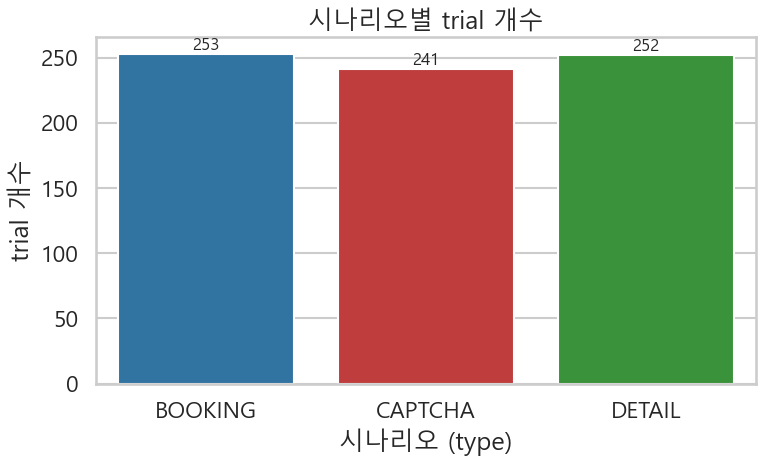

In [10]:
# 시나리오별 trial 개수와 라벨 unique 확인
dataset_overview = pd.DataFrame(
    {
        "trial 수": raw_df.groupby("type").size(),
        "trial_id unique": raw_df.groupby("type")["trial_id"].nunique(),
        "label unique 수": raw_df.groupby("type")["label"].nunique(),
    }
).sort_index()

print("시나리오별 trial 카운트:")
display(dataset_overview)
print(f"\n라벨 unique: {raw_df['label'].unique().tolist()} (모두 ALLOW 인지 확인)")

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=raw_df, x="type",
    order=sorted(raw_df["type"].unique()),
    hue="type", palette=TYPE_PALETTE, legend=False,
    ax=ax,
)
ax.set_title("시나리오별 trial 개수")
ax.set_xlabel("시나리오 (type)")
ax.set_ylabel("trial 개수")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=12)
plt.tight_layout()
plt.show()

## 2. 전처리

### 2-1. 분석 대상 feature 선별

metric 컬럼 중 다음 두 조건을 만족하는 feature 만 분석에 사용합니다.
1. 모든 값이 NaN 이 아닌 feature (= 적어도 한 trial 에서는 값이 있음)
2. 분산이 0 이 아닌 feature (= 모든 trial 이 같은 값이 아님)

**제외되는 feature 의 데이터적 의미**
- **전부 결측**: 해당 feature 는 ALLOW 데이터 수집 파이프라인에서 채워지지 않습니다 (DOM 의존 feature 가 대표적: `click_offset_*`, `mouse_hover_dwell_time_ms` 등).
- **분산 0**: ALLOW 데이터에서 모든 trial 이 동일한 값을 가집니다. 예를 들어 `misclick_rate=0` 으로 일정하면 "휴먼은 오클릭이 거의 없다" 는 사실 자체는 의미 있지만, **시나리오 비교**에는 정보가 없으므로 제외합니다.

출력에서 "제외 feature 목록" 을 보고, 잃는 정보가 분석 의도와 충돌하지 않는지 확인합니다.

In [11]:
# metric 컬럼 추출 + 사용 가능 feature 선별
# - 모든 값이 NaN 인 feature 제외
# - 분산이 0 (모든 값이 동일) 인 feature 제외
metric_cols = [col for col in raw_df.columns if col not in ID_COLS]
metric_df = raw_df[metric_cols].apply(pd.to_numeric, errors="coerce")

non_empty_features = metric_df.notna().sum().sort_values(ascending=False)
zero_variance_features = metric_df.nunique(dropna=True)
usable_features = [
    col for col in metric_cols
    if non_empty_features[col] > 0 and zero_variance_features[col] > 1
]

dropped_features = sorted(set(metric_cols) - set(usable_features))

analysis_df = pd.concat([raw_df[ID_COLS], metric_df[usable_features]], axis=1)
ordered_types = list(DATASETS.keys())

print(f"전체 trial 행 수: {len(raw_df)}")
print(f"metric 컬럼 총 수: {len(metric_cols)}")
print(f"분석 대상 feature: {len(usable_features)}개")
print(f"제외 feature (전부 결측 또는 분산 0): {len(dropped_features)}개")
if dropped_features:
    print("\n제외 feature 목록 (한글명):")
    for f in dropped_features:
        print(f"  - {feature_label(f)}")

전체 trial 행 수: 746
metric 컬럼 총 수: 34
분석 대상 feature: 25개
제외 feature (전부 결측 또는 분산 0): 9개

제외 feature 목록 (한글명):
  - click_offset_from_element_center_px
  - click_offset_variance_px
  - 순서 일관성 (click_sequence_consistency_score)
  - 즉시 클릭 비율 (immediate_post_render_click_rate)
  - inter_element_move_interval_std_ms
  - 오클릭 비율 (misclick_rate)
  - 재클릭 비율 (reclick_rate)
  - 활성 후 클릭 (time_from_element_clickable_to_click_ms)
  - 노출 후 클릭 (time_from_element_visible_to_click_ms)


### 2-2. 시나리오별 결측률 점검

사용 feature 중 시나리오마다 결측률이 다른 feature 가 있는지 확인합니다.

**표 (`null_rate_kr`)** — 행=feature, 열=시나리오, 값=결측률(0~1).
- `최대 결측률` 컬럼이 큰 feature 는 일부 시나리오에서만 누락이라는 신호
- 시나리오 모두 0 이면 깨끗한 feature

**히트맵** — 색이 어두울수록 결측률 높음.
- 한 시나리오 컬럼만 진하면 그 시나리오의 수집 차이 (예: CAPTCHA 에서만 특정 feature 누락)
- 모든 시나리오가 비슷하게 진하면 데이터 자체의 한계

결측률이 큰 feature 는 SMD 결과의 신뢰도가 낮으므로 §3 의 해석 시 우선순위를 낮춥니다.

feature 별 시나리오 결측률 (상위 15개)


,BOOKING,DETAIL,CAPTCHA,최대 결측률
평균 dwell (mouse_hover_dwell_time_ms),0.8933,1.0000,1.0000,1.0000
좌표 반복률 (click_position_repeat_rate),0.0000,0.8452,0.0000,0.8452
inter_click_interval_ms,0.0040,0.8452,0.0000,0.8452
저크 평균 (mouse_jerk_mean),0.0000,0.0952,0.0664,0.0952
가속도 변화 (mouse_acceleration_mean),0.0000,0.0675,0.0000,0.0675
속도 변화 (mouse_speed_change_mean),0.0000,0.0675,0.0000,0.0675
경로 곡률 (mouse_path_curvature_mean),0.0000,0.0675,0.0000,0.0675
정지 구간 수 (mouse_stop_segment_count),0.0000,0.0556,0.0000,0.0556
최대 속도 (mouse_max_speed_px_per_ms),0.0000,0.0556,0.0000,0.0556
고정점 방문률 (edge_or_fixed_point_visit_rate),0.0000,0.0556,0.0000,0.0556


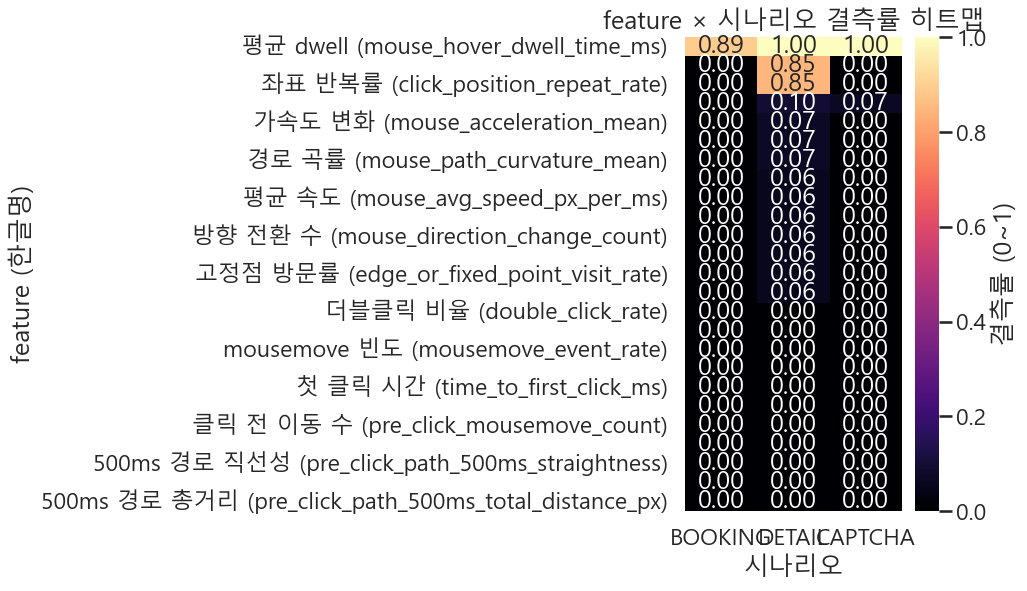

In [12]:
# 사용 feature 의 시나리오별 결측률 점검
null_rate = pd.concat(
    {
        type_name: analysis_df.loc[analysis_df["type"] == type_name, usable_features].isna().mean()
        for type_name in ordered_types
    },
    axis=1,
)
null_rate["최대 결측률"] = null_rate[ordered_types].max(axis=1)
null_rate_kr = null_rate.copy()
null_rate_kr.index = [feature_label(f) for f in null_rate_kr.index]

print("feature 별 시나리오 결측률 (상위 15개)")
display(null_rate_kr.sort_values("최대 결측률", ascending=False).head(15))

# 결측률 heatmap
fig, ax = plt.subplots(figsize=(10, max(6, len(usable_features) * 0.25)))
sorted_idx = null_rate.sort_values(by=ordered_types, ascending=False).index
sns.heatmap(
    null_rate.loc[sorted_idx, ordered_types]
    .rename(index={f: feature_label(f) for f in sorted_idx}),
    cmap="magma", annot=True, fmt=".2f", ax=ax,
    cbar_kws={"label": "결측률 (0~1)"},
)
ax.set_title("feature × 시나리오 결측률 히트맵")
ax.set_xlabel("시나리오")
ax.set_ylabel("feature (한글명)")
plt.tight_layout()
plt.show()

## 3. 기본 분석

### 3-0. 시나리오별 기술 통계

각 feature 가 시나리오별로 어떤 분포를 가지는지 가장 기본적인 5개 통계량으로 확인합니다.

**표 구조** — 행=`(feature, 통계량)` MultiIndex, 열=시나리오. transpose 되어 있어 한 화면에서 feature 별 시나리오 비교가 가능합니다.

**보는 법**
- `mean` 행에서 시나리오 간 값이 크게 다르면 평균 차이가 있는 feature
- `std` 행에서 한 시나리오만 std 가 크면 그 시나리오에서 행동 다양성이 큼
- `min` / `max` 가 시나리오마다 크게 다르면 분포 범위 자체가 다름

이 표는 다음 §3 의 SMD 분석 결과를 검증하는 용도로도 사용합니다 (SMD 가 큰 feature 의 mean 차이가 실제로 표에 나타나는지).

In [13]:
# 시나리오별 기술 통계 요약 (mean / median / std / min / max)
summary_stats = (
    analysis_df.groupby("type")[usable_features]
    .agg(["mean", "median", "std", "min", "max"])
    .transpose()
)
summary_stats.index = pd.MultiIndex.from_tuples(
    [(feature_label(f), stat) for f, stat in summary_stats.index],
    names=["feature (한글명)", "통계량"],
)
print("시나리오별 기술 통계 (상위 30행)")
display(summary_stats.head(30))

시나리오별 기술 통계 (상위 30행)


type                                            BOOKING      CAPTCHA  \
feature (한글명)                       통계량                                
저크 평균 (mouse_jerk_mean)             mean         0.0002       0.0001   
                                    median       0.0002       0.0001   
                                    std          0.0001       0.0001   
                                    min          0.0000       0.0000   
                                    max          0.0005       0.0005   
더블클릭 비율 (double_click_rate)         mean         0.1780       0.2481   
                                    median       0.1667       0.3333   
                                    std          0.1827       0.2482   
                                    min          0.0000       0.0000   
                                    max          0.8235       0.7500   
오버슈트 여부 (mouse_overshoot_flag)      mean         0.0277       0.0000   
                                    median       0.0000       0.0000   
                                    std          0.1643       0.0000   
                                    min          0.0000       0.0000   
                                    max          1.0000       0.0000   
mousemove 빈도 (mousemove_event_rate) mean         6.8385       8.6235   
                                    median       6.9914       8.9050   
                                    std          3.2323       3.8166   
                                    min          0.0605       0.1470   
                                    max         15.5006      16.4186   
클릭 전 스크롤 (pre_click_scroll_flag)    mean         0.0005       0.0000   
                                    median       0.0000       0.0000   
                                    std          0.0079       0.0000   
                                    min          0.0000       0.0000   
                                    max          0.1250       0.0000   
첫 클릭 시간 (time_to_first_click_ms)    mean     9,202.8379   4,060.3444   
                                    median   5,671.0000   1,814.0000   
                                    std     13,743.4587  24,143.7014   
                                    min        144.0000     144.0000   
                                    max    140,945.0000 370,785.0000   

type                                                DETAIL  
feature (한글명)                       통계량                     
저크 평균 (mouse_jerk_mean)             mean            0.0002  
                                    median          0.0001  
                                    std             0.0001  
                                    min             0.0000  
                                    max             0.0009  
더블클릭 비율 (double_click_rate)         mean            0.0137  
                                    median          0.0000  
                                    std             0.0771  
                                    min             0.0000  
                                    max             0.6667  
오버슈트 여부 (mouse_overshoot_flag)      mean            0.0000  
                                    median          0.0000  
                                    std             0.0000  
                                    min             0.0000  
                                    max             0.0000  
mousemove 빈도 (mousemove_event_rate) mean            6.7763  
                                    median          6.3647  
                                    std             4.6931  
                                    min             0.0005  
                                    max            43.4783  
클릭 전 스크롤 (pre_click_scroll_flag)    mean            0.0000  
                                    median          0.0000  
                                    std             0.0000  
                                    min             0.0000  
                                    max             0.0000  
첫 클릭 시간 (time_to_first_click_ms)    mean      36

### 3-1. Pairwise SMD 3쌍 + feature 순위

두 단계 출력입니다.

**(1) `pairwise_smd` 표 (75행 = 25 feature × 3 비교 쌍)**
- `비교 쌍`: 어느 두 시나리오 비교인지 (예: `BOOKING vs DETAIL`)
- `SMD`: 부호 있음. 양수면 좌측 시나리오 평균이 더 큼, 음수면 우측이 더 큼
- `|SMD|`: 부호 없는 효과 크기 (해석은 §0 의 SMD 표 참고)
- `SMD level`: 자동 분류된 효과 크기 등급 (huge/very_large/large/medium/small/negligible)
- `{시나리오} 평균`, `{시나리오} 유효 수`: 실제 평균 값과 결측 제외 후 표본 수

상위 20개 (|SMD| 내림차순) 만 보여주므로, 두드러진 차이가 어느 쌍에서 나는지 우선 확인합니다.

**(2) `feature_rank` 표 (top 12 feature)**
- 한 feature 가 3쌍 비교에서 받은 |SMD| 중 **최댓값** 으로 순위 산출
- 이 top 12 가 §3-1, §3-2, §3-3 시각화의 분석 대상

**해석 시 주의**
- 같은 feature 라도 비교 쌍마다 |SMD| 가 다를 수 있습니다. max(|SMD|) 가 1.5 이상(very_large) 이라도 다른 두 쌍에서는 작을 수 있어, **§3-1 의 pairwise heatmap** 으로 어느 쌍에서 차이가 큰지 같이 확인해야 합니다.
- pooled_std 가 0 인 feature 는 SMD = NaN 으로 표시됩니다 (해당 비교 쌍에서 두 시나리오 모두 분산이 없는 경우).

In [14]:
# Pairwise SMD 3쌍 — BOOKING↔DETAIL, BOOKING↔CAPTCHA, DETAIL↔CAPTCHA
PAIR_LABEL_KR = {
    ("BOOKING", "DETAIL"):  "BOOKING vs DETAIL",
    ("BOOKING", "CAPTCHA"): "BOOKING vs CAPTCHA",
    ("DETAIL",  "CAPTCHA"): "DETAIL vs CAPTCHA",
}

def standardized_mean_difference(left: pd.Series, right: pd.Series) -> float:
    """두 시리즈의 SMD = (mean_left - mean_right) / pooled_std.
    
    pooled_std 가 0 이거나 표본이 부족하면 NaN 반환.
    """
    left = left.dropna()
    right = right.dropna()
    if len(left) < 2 or len(right) < 2:
        return np.nan
    pooled_std = np.sqrt((left.var(ddof=1) + right.var(ddof=1)) / 2)
    if pooled_std == 0 or np.isnan(pooled_std):
        return np.nan
    return (left.mean() - right.mean()) / pooled_std

def smd_level(abs_smd: float) -> str:
    if pd.isna(abs_smd):
        return "NaN"
    if abs_smd >= 3.0:  return "huge"
    if abs_smd >= 1.5:  return "very_large"
    if abs_smd >= 0.8:  return "large"
    if abs_smd >= 0.5:  return "medium"
    if abs_smd >= 0.2:  return "small"
    return "negligible"

pairwise_rows = []
for left_type, right_type in combinations(ordered_types, 2):
    pair_kr = PAIR_LABEL_KR[(left_type, right_type)]
    left_df = analysis_df.loc[analysis_df["type"] == left_type, usable_features]
    right_df = analysis_df.loc[analysis_df["type"] == right_type, usable_features]
    for feature in usable_features:
        smd = standardized_mean_difference(left_df[feature], right_df[feature])
        pairwise_rows.append({
            "비교 쌍": pair_kr,
            "feature": feature,
            "feature 한글명": FEATURE_NAME_KR.get(feature, feature),
            "feature 그룹": group_label(feature),
            "SMD": smd,
            f"{left_type} 평균":  left_df[feature].mean(),
            f"{right_type} 평균": right_df[feature].mean(),
            f"{left_type} 유효 수":  int(left_df[feature].notna().sum()),
            f"{right_type} 유효 수": int(right_df[feature].notna().sum()),
        })

pairwise_smd = pd.DataFrame(pairwise_rows)
pairwise_smd["|SMD|"] = pairwise_smd["SMD"].abs()
pairwise_smd["SMD level"] = pairwise_smd["|SMD|"].apply(smd_level)

print("Pairwise SMD 상위 20개 (|SMD| 내림차순)")
display(
    pairwise_smd.sort_values("|SMD|", ascending=False)
    .drop(columns=["feature"]).head(20)
)

# feature 별 max(|SMD|) 로 순위 산출
feature_rank = (
    pairwise_smd.groupby("feature", as_index=True)["|SMD|"]
    .max()
    .sort_values(ascending=False)
)
top_features = feature_rank.head(12).index.tolist()

print("\nfeature 순위 (max(|SMD|) 기준 상위 12개)")
feature_rank_kr = feature_rank.head(12).to_frame("max(|SMD|)")
feature_rank_kr.insert(0, "feature 한글명", [FEATURE_NAME_KR.get(f, f) for f in feature_rank_kr.index])
feature_rank_kr.insert(1, "feature 그룹", [group_label(f) for f in feature_rank_kr.index])
feature_rank_kr.insert(3, "SMD level", feature_rank_kr["max(|SMD|)"].apply(smd_level))
feature_rank_kr.index = [feature_label(f) for f in feature_rank_kr.index]
feature_rank_kr.index.name = "feature"
display(feature_rank_kr)

Pairwise SMD 상위 20개 (|SMD| 내림차순)


,비교 쌍,feature 한글명,feature 그룹,SMD,BOOKING 평균,DETAIL 평균,BOOKING 유효 수,DETAIL 유효 수,CAPTCHA 평균,CAPTCHA 유효 수,|SMD|,SMD level
10,BOOKING vs DETAIL,정지 구간 수,마우스,2.0102,12.9526,3.6387,253.0000,238.0000,NaN,NaN,2.0102,very_large
45,BOOKING vs CAPTCHA,총 이동 거리,마우스,1.7351,"3,469.8888",NaN,253.0000,NaN,"1,444.6234",241.0000,1.7351,very_large
17,BOOKING vs DETAIL,방향 전환 수,마우스,1.6871,22.3123,6.9790,253.0000,238.0000,NaN,NaN,1.6871,very_large
38,BOOKING vs CAPTCHA,최대 속도,마우스,1.4544,6.1768,NaN,253.0000,NaN,2.6313,241.0000,1.4544,large
20,BOOKING vs DETAIL,총 이동 거리,마우스,1.3868,"3,469.8888","1,203.3806",253.0000,238.0000,NaN,NaN,1.3868,large
35,BOOKING vs CAPTCHA,정지 구간 수,마우스,1.3124,12.9526,NaN,253.0000,NaN,7.6266,241.0000,1.3124,large
51,DETAIL vs CAPTCHA,더블클릭 비율,클릭,-1.2757,NaN,0.0137,NaN,252.0000,0.2481,241.0000,1.2757,large
1,BOOKING vs DETAIL,더블클릭 비율,클릭,1.1715,0.1780,0.0137,253.0000,252.0000,NaN,NaN,1.1715,large
18,BOOKING vs DETAIL,경로 직선성,마우스,-1.1536,0.1877,0.4892,253.0000,238.0000,NaN,NaN,1.1536,large
68,DETAIL vs CAPTCHA,경로 직선성,마우스,1.1477,NaN,0.4892,NaN,238.0000,0.1745,241.0000,1.1477,large



feature 순위 (max(|SMD|) 기준 상위 12개)


,feature 한글명,feature 그룹,max(|SMD|),SMD level
feature,,,,
정지 구간 수 (mouse_stop_segment_count),정지 구간 수,마우스,2.0102,very_large
총 이동 거리 (mouse_total_travel_distance_px),총 이동 거리,마우스,1.7351,very_large
방향 전환 수 (mouse_direction_change_count),방향 전환 수,마우스,1.6871,very_large
최대 속도 (mouse_max_speed_px_per_ms),최대 속도,마우스,1.4544,large
더블클릭 비율 (double_click_rate),더블클릭 비율,클릭,1.2757,large
경로 직선성 (mouse_path_straightness_score),경로 직선성,마우스,1.1536,large
속도 변화 (mouse_speed_change_mean),속도 변화,마우스,0.8909,large
가속도 변화 (mouse_acceleration_mean),가속도 변화,마우스,0.8686,large
저크 평균 (mouse_jerk_mean),저크 평균,마우스,0.8239,large


### 3-1. 분포 시각화 (top 12 boxplot)

feature 별 max(|SMD|) 가 큰 상위 12개를 시나리오별 박스플롯으로 비교합니다.

#### 3-1-A. 시나리오별 박스플롯

**그래프 구조** — 4행 × 3열 = 12 subplot. 각 subplot 의 x 축 = 시나리오 (BOOKING / DETAIL / CAPTCHA), y 축 = feature 값.

**박스플롯 읽는 법**
- 박스 중앙 가로선 = **median** (50% 분위)
- 박스 위/아래 = **IQR** (Q1=25% ~ Q3=75%)
- 수염(whisker) = 1.5×IQR 범위 내의 최댓값/최솟값
- 점 = **이상치** (수염 바깥 값)

**시나리오 비교 포인트**
- **박스 위치 차이** → 시나리오 간 평균/median 차이 (SMD 의 시각적 근거)
- **박스 크기 차이** → 시나리오 간 분산 차이
- **이상치가 많은 feature** → SMD 가 평균에만 의존하므로 신뢰도 낮음. 본문 SMD 결과를 보수적으로 해석

각 subplot 의 제목에 `한글명 / 영문명 / max|SMD| 값 / SMD level / feature 그룹` 이 표시됩니다.

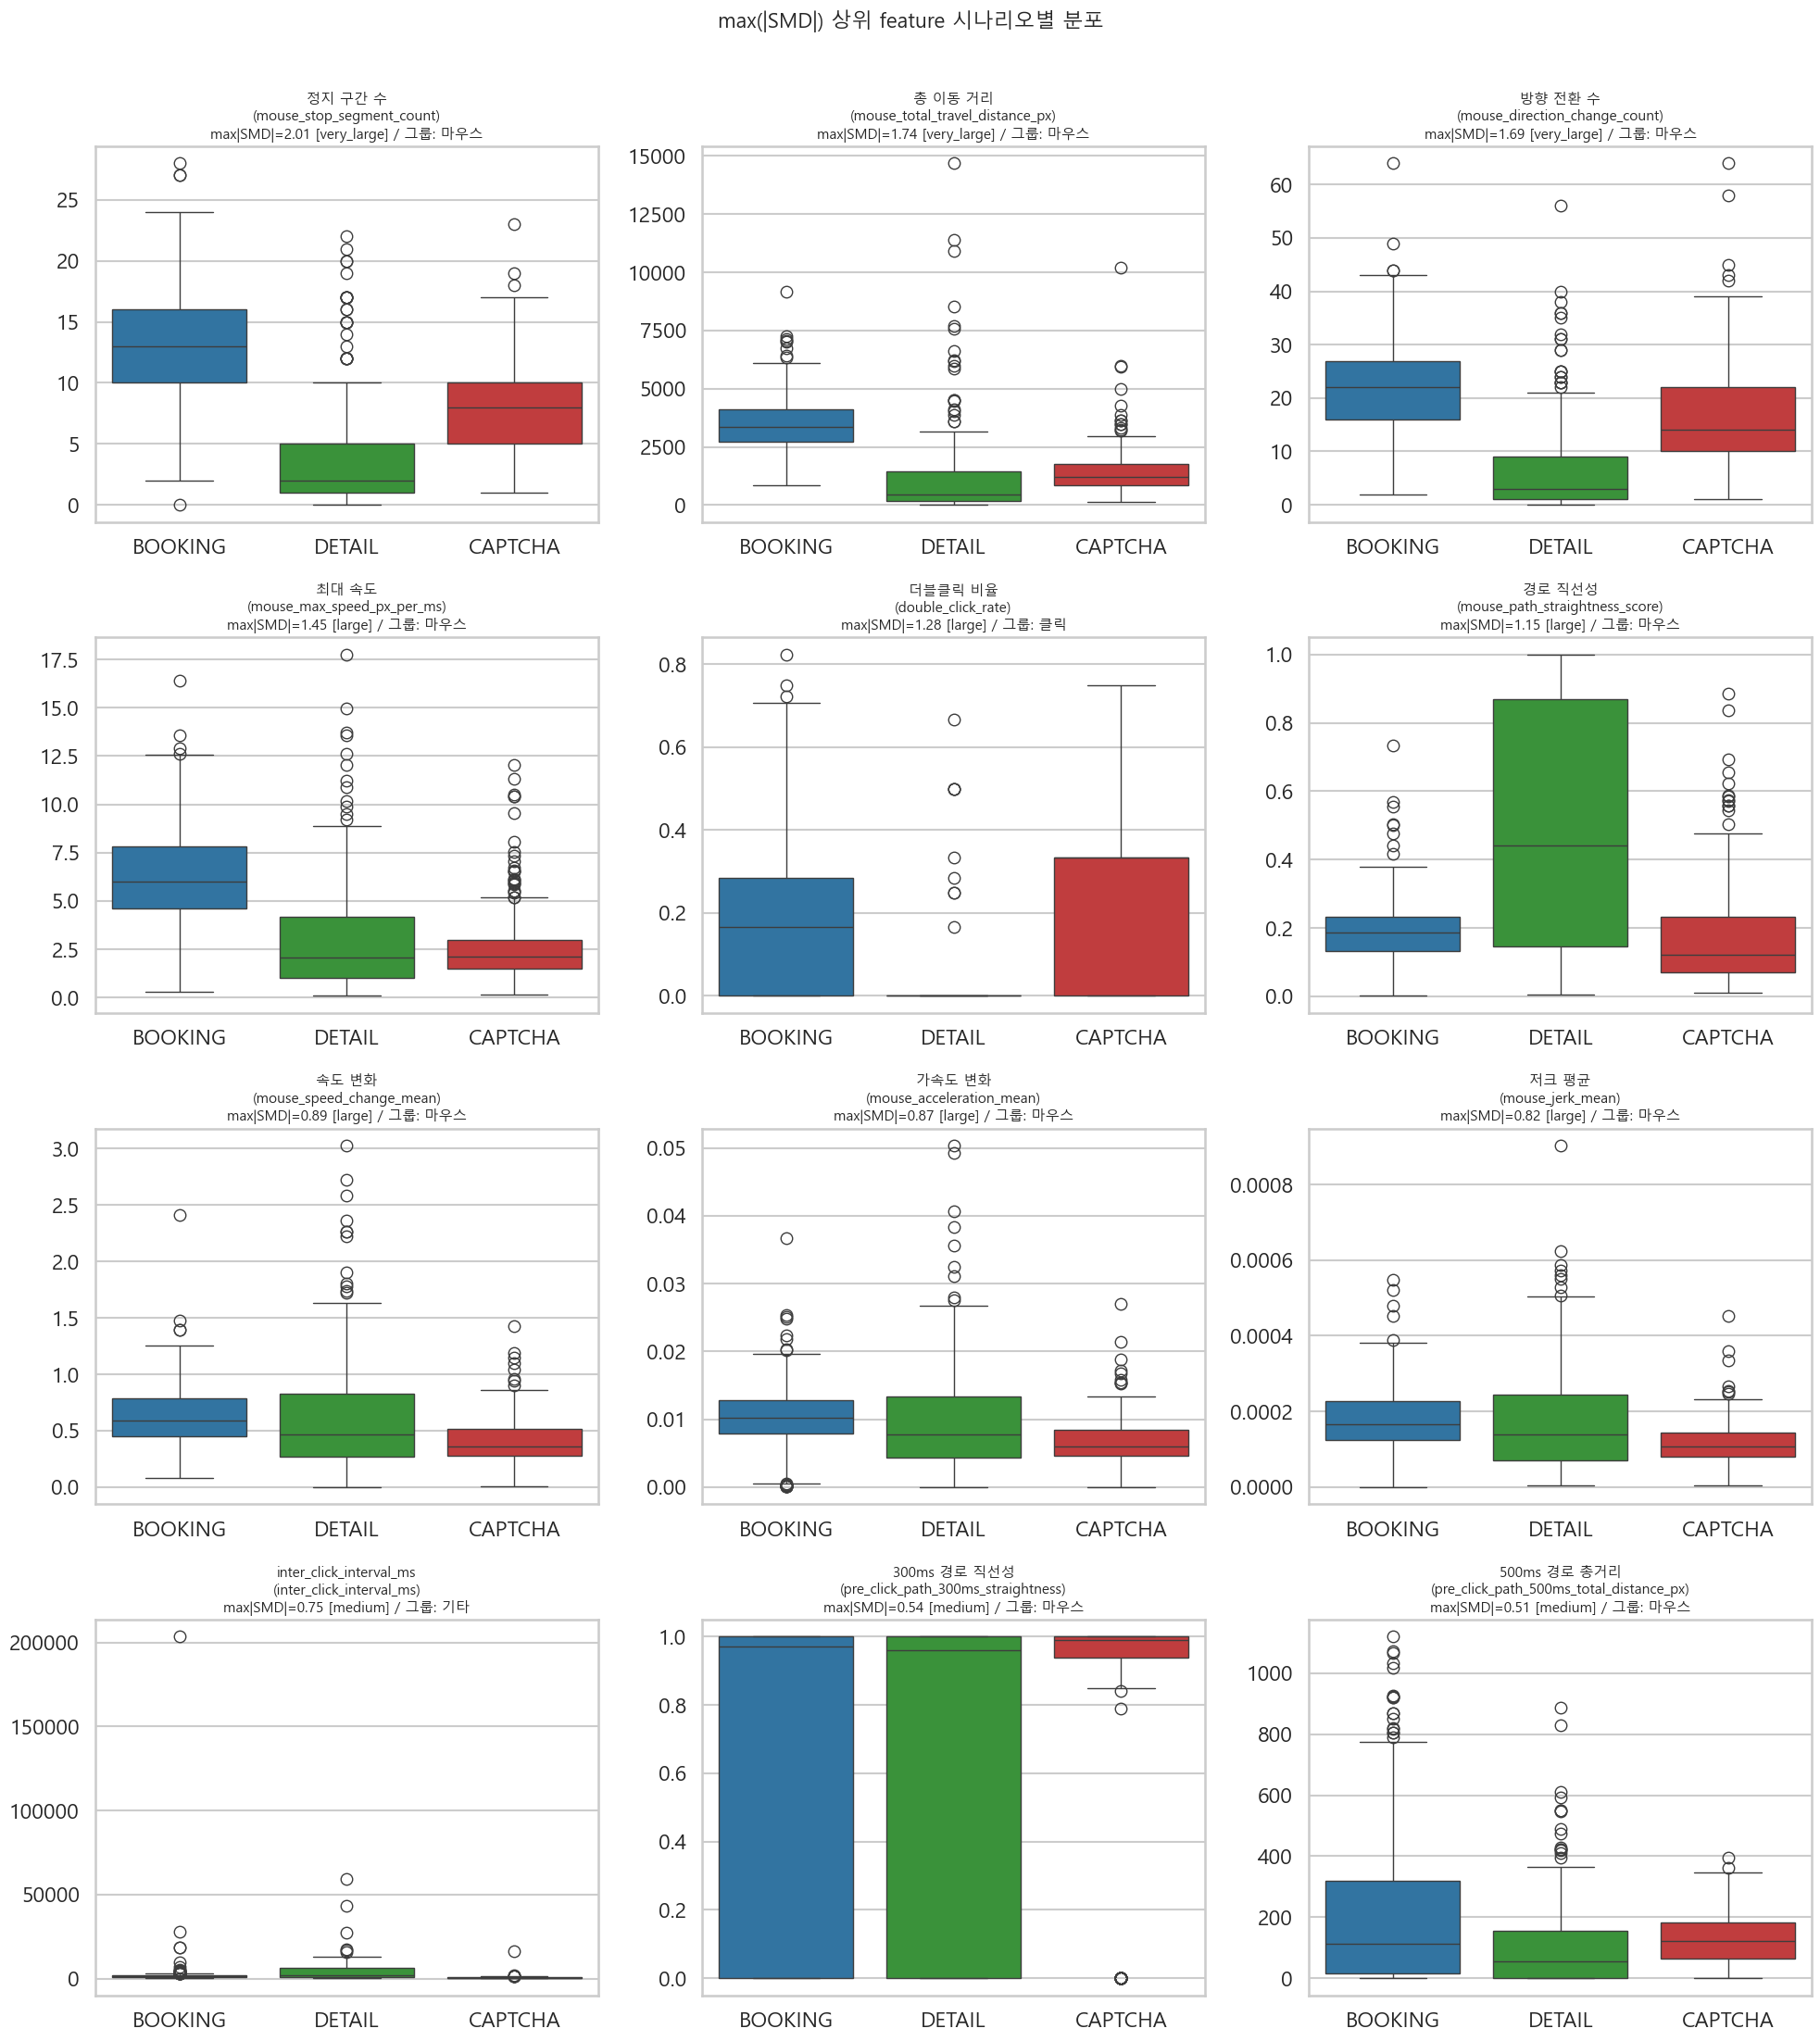

In [15]:
# top 12 feature 박스플롯 (4 행 × 3 열)
fig, axes = plt.subplots(4, 3, figsize=(20, 22))
axes = axes.flatten()

for ax, feature in zip(axes, top_features):
    sns.boxplot(
        data=analysis_df,
        x="type", y=feature,
        order=ordered_types,
        hue="type", hue_order=ordered_types,
        palette=TYPE_PALETTE, legend=False,
        ax=ax,
    )
    max_smd = float(feature_rank[feature])
    ax.set_title(
        f"{FEATURE_NAME_KR.get(feature, feature)}\n"
        f"({feature})\n"
        f"max|SMD|={max_smd:.2f} [{smd_level(max_smd)}] / 그룹: {group_label(feature)}",
        fontsize=11,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(top_features):]:
    ax.axis("off")

fig.suptitle(
    "max(|SMD|) 상위 feature 시나리오별 분포",
    y=1.005, fontsize=16,
)
plt.tight_layout()
plt.show()

#### 3-1-B. Pairwise |SMD| 히트맵 (top 20 feature × 3 비교 쌍)

어느 두 시나리오 비교에서 차이가 큰지 한눈에 보기 위한 히트맵입니다.

**그래프 구조**
- 행 = max(|SMD|) 상위 20 feature (한글명 표기)
- 열 = 3 비교 쌍 (BOOKING vs DETAIL / BOOKING vs CAPTCHA / DETAIL vs CAPTCHA)
- 색 = |SMD| 값 (밝은 노랑 → 진한 빨강)

**해석 패턴**
- **한 행에서 한 쌍만 진함** → 그 두 시나리오 사이에서만 차이가 두드러지는 feature (예: BOOKING vs DETAIL 만 진하면 BOOKING 과 DETAIL 의 행동이 특히 다름)
- **한 행 전체가 진함** → 어떤 두 시나리오를 비교해도 차이가 큰 feature (시나리오 식별력이 가장 높음)
- **한 열 전체가 진함** → 그 비교 쌍의 두 시나리오가 전반적으로 다름 (예: BOOKING vs CAPTCHA 열이 전체적으로 진하면 두 시나리오가 가장 멀리 떨어진 페어)

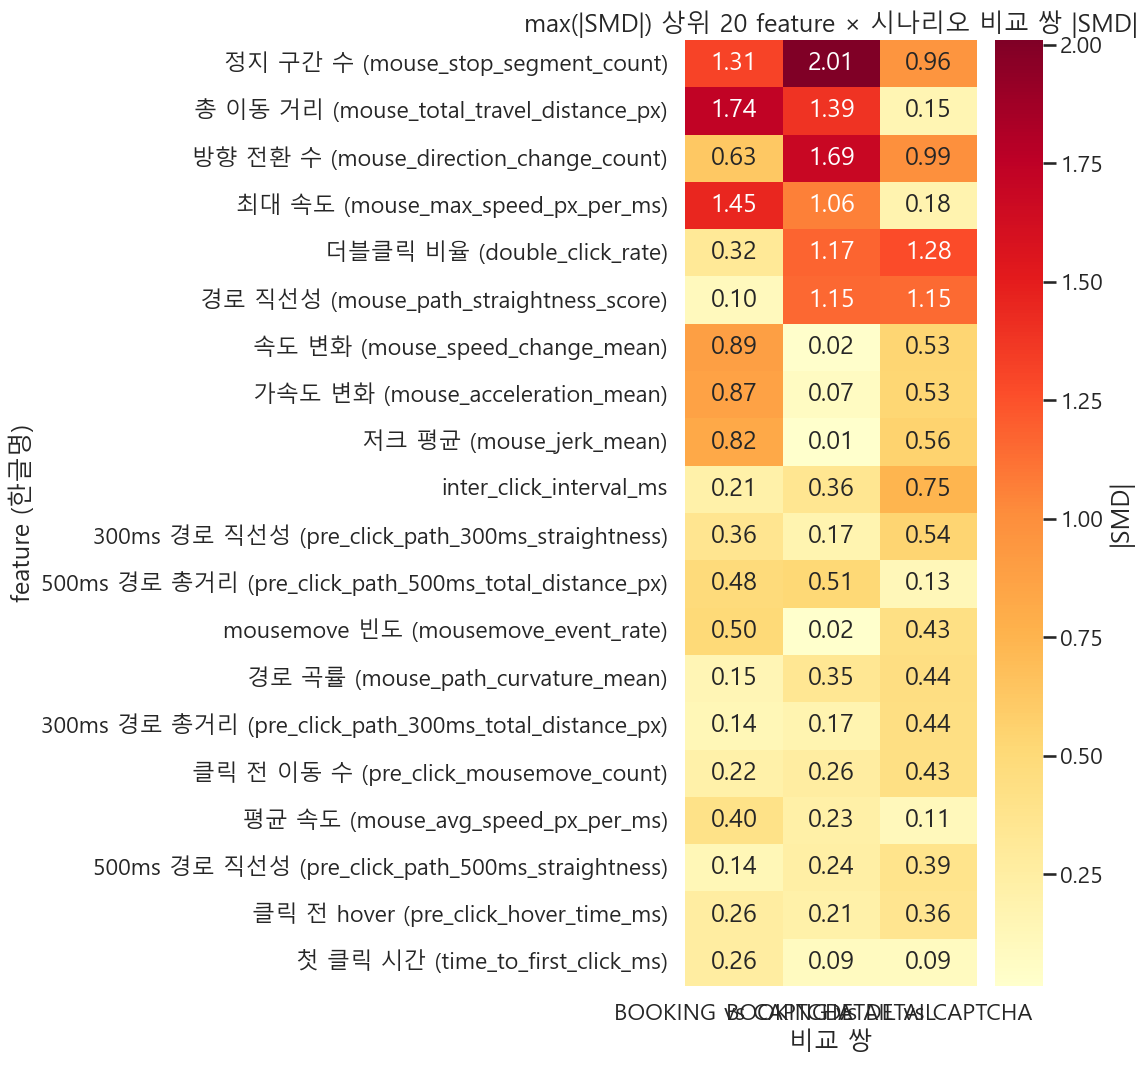

In [16]:
# Pairwise |SMD| 매트릭스 — 어느 두 시나리오 비교에서 차이가 큰지 한눈에
pairwise_pivot = pairwise_smd.pivot(index="feature", columns="비교 쌍", values="|SMD|")
pairwise_pivot = pairwise_pivot.loc[feature_rank.index[:20]]
pairwise_pivot.index = [feature_label(f) for f in pairwise_pivot.index]

fig, ax = plt.subplots(figsize=(11, 11))
sns.heatmap(
    pairwise_pivot,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={"label": "|SMD|"},
    ax=ax,
)
ax.set_title("max(|SMD|) 상위 20 feature × 시나리오 비교 쌍 |SMD|")
ax.set_xlabel("비교 쌍")
ax.set_ylabel("feature (한글명)")
plt.tight_layout()
plt.show()

### 3-2. 상관관계 분석 (시나리오별)

**그래프 구조** — 가로로 3개 히트맵 (BOOKING / DETAIL / CAPTCHA), 각 히트맵은 max(|SMD|) 상위 10 feature 끼리의 Pearson 상관계수 매트릭스.

**색 의미**
- 빨강 = 양의 상관 (한 쪽이 크면 다른 쪽도 큼, 예: 마우스 이동 거리 ↑ → 평균 속도 ↑)
- 파랑 = 음의 상관 (한 쪽이 크면 다른 쪽은 작음)
- 흰색 = 무상관 (값 ≈ 0)
- 대각선은 자기 자신 상관이라 항상 1 (빨강)

**시나리오 간 비교 포인트**
- **세 히트맵이 비슷** → feature 간 동조 패턴이 시나리오와 무관 → 휴먼 마우스 행동의 안정성 시사. 모델 학습 시 시나리오 통합 가능
- **세 히트맵이 다름** → 시나리오마다 feature 가 조합되는 방식이 다름 → 모델 학습 시 시나리오 정보를 함께 입력하거나 시나리오별 모델 분리 검토 필요
- **특정 셀(feature 쌍)의 부호가 바뀜** → 시나리오에 따라 두 feature 의 관계가 정반대로 작동 (해석 시 매우 주의)

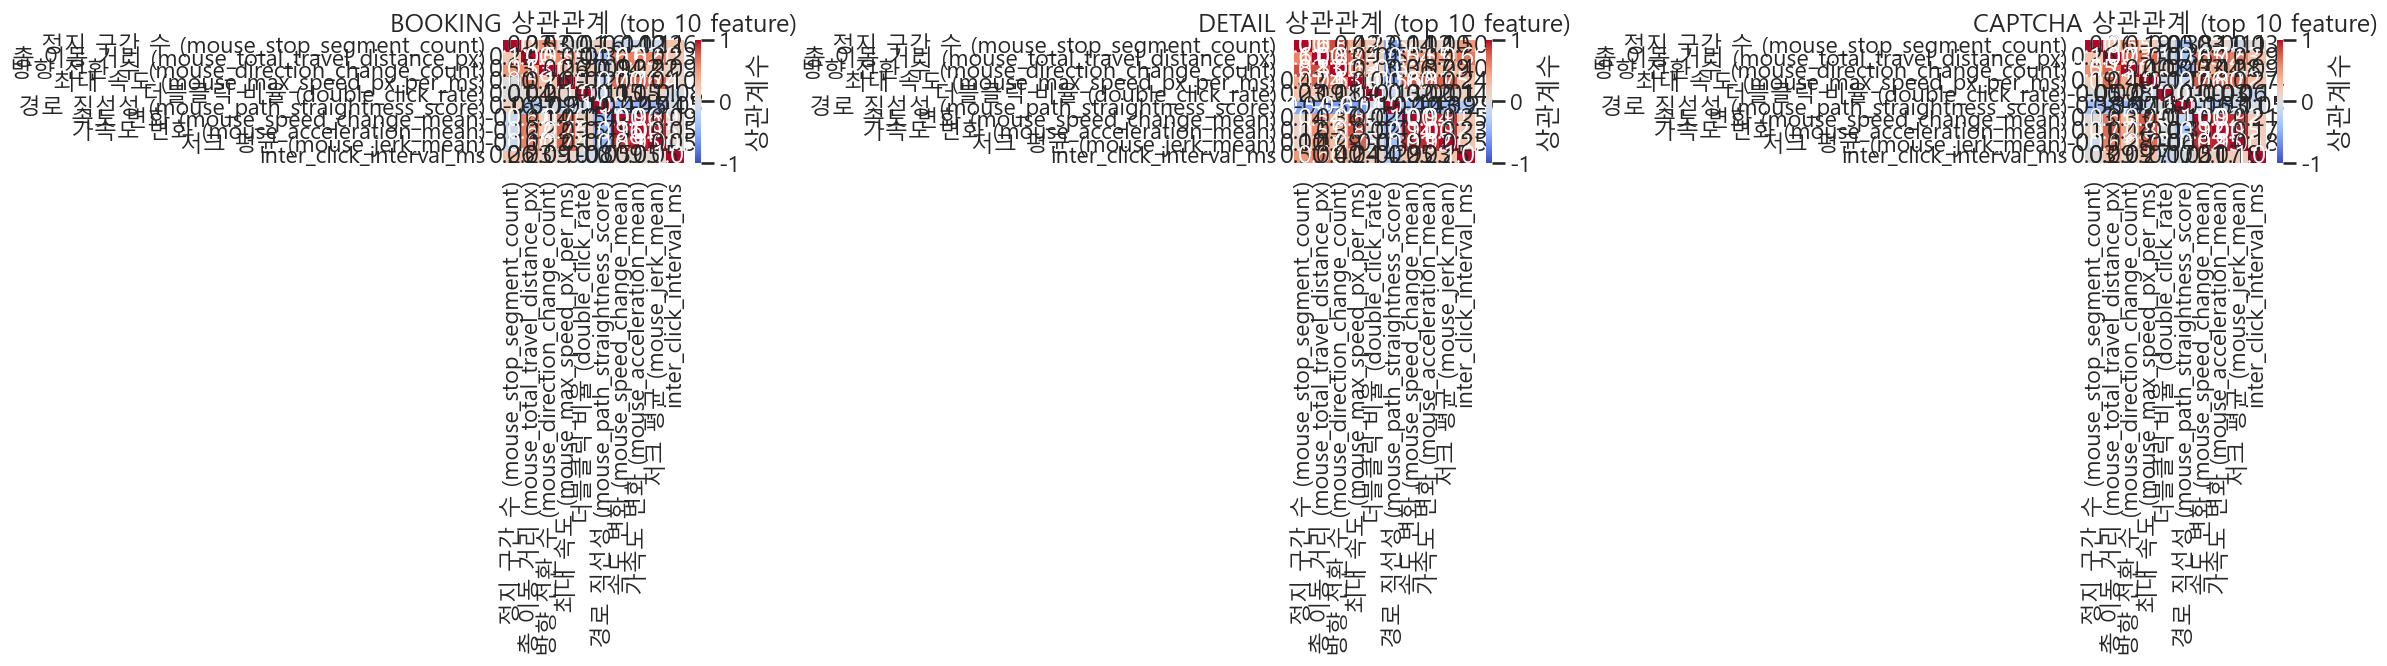

In [17]:
corr_features = feature_rank.head(10).index.tolist()
corr_features_kr = [feature_label(f) for f in corr_features]

fig, axes = plt.subplots(1, len(ordered_types), figsize=(8 * len(ordered_types), 7))
axes = np.atleast_1d(axes)

for ax, type_name in zip(axes, ordered_types):
    corr = analysis_df.loc[analysis_df["type"] == type_name, corr_features].corr()
    corr.index = corr_features_kr
    corr.columns = corr_features_kr
    sns.heatmap(
        corr, cmap="coolwarm", center=0,
        annot=True, fmt=".2f",
        vmin=-1, vmax=1,
        cbar_kws={"label": "상관계수"},
        ax=ax,
    )
    ax.set_title(f"{type_name} 상관관계 (top 10 feature)")

plt.tight_layout()
plt.show()

### 3-3. PCA 산점도

max(|SMD|) 상위 15 feature 로 2-D PCA(주성분 분석) 산점도를 그립니다.

**전처리** — PCA 는 결측을 허용하지 않으므로:
1. 결측은 feature 중앙값으로 imputation
2. StandardScaler 로 모든 feature 를 평균 0, 표준편차 1 로 표준화 (단위 무관 비교)
3. PCA 로 2D 로 축약 (`random_state=42` 재현성 고정)

**설명력 표** — PC1, PC2 가 전체 분산의 몇 % 를 설명하는가.
- 누적 ≥ 0.5 → 2D 로 충분히 표현 가능, 산점도 분리 패턴 신뢰도 높음
- 누적 < 0.3 → 정보 손실 큼, 산점도는 참고용으로만

**산점도** — x=PC1, y=PC2, 색=시나리오.
- **시나리오별 색이 명확히 분리** → 그 15 feature 조합만으로도 시나리오를 구분할 수 있음 → 시나리오 라벨 분류기 학습 가능
- **세 색이 전체적으로 겹침** → 마우스 행동만으로는 시나리오 차이가 작음 → "시나리오 무관하게 휴먼 행동이 안정적" 이라는 결론 자체가 의미 있음
- **부분 분리** → 일부 시나리오만 분리 (예: CAPTCHA 만 떨어져 있고 BOOKING/DETAIL 겹침) → 그 시나리오만 행동 패턴이 두드러지게 다름

PCA 설명력:


,성분,설명 분산 비율,누적 설명 분산
0,PC1,0.3293,0.3293
1,PC2,0.1714,0.5007



사용한 feature (max(|SMD|) 상위 15개):
  - 정지 구간 수 (mouse_stop_segment_count)
  - 총 이동 거리 (mouse_total_travel_distance_px)
  - 방향 전환 수 (mouse_direction_change_count)
  - 최대 속도 (mouse_max_speed_px_per_ms)
  - 더블클릭 비율 (double_click_rate)
  - 경로 직선성 (mouse_path_straightness_score)
  - 속도 변화 (mouse_speed_change_mean)
  - 가속도 변화 (mouse_acceleration_mean)
  - 저크 평균 (mouse_jerk_mean)
  - inter_click_interval_ms
  - 300ms 경로 직선성 (pre_click_path_300ms_straightness)
  - 500ms 경로 총거리 (pre_click_path_500ms_total_distance_px)
  - mousemove 빈도 (mousemove_event_rate)
  - 경로 곡률 (mouse_path_curvature_mean)
  - 300ms 경로 총거리 (pre_click_path_300ms_total_distance_px)


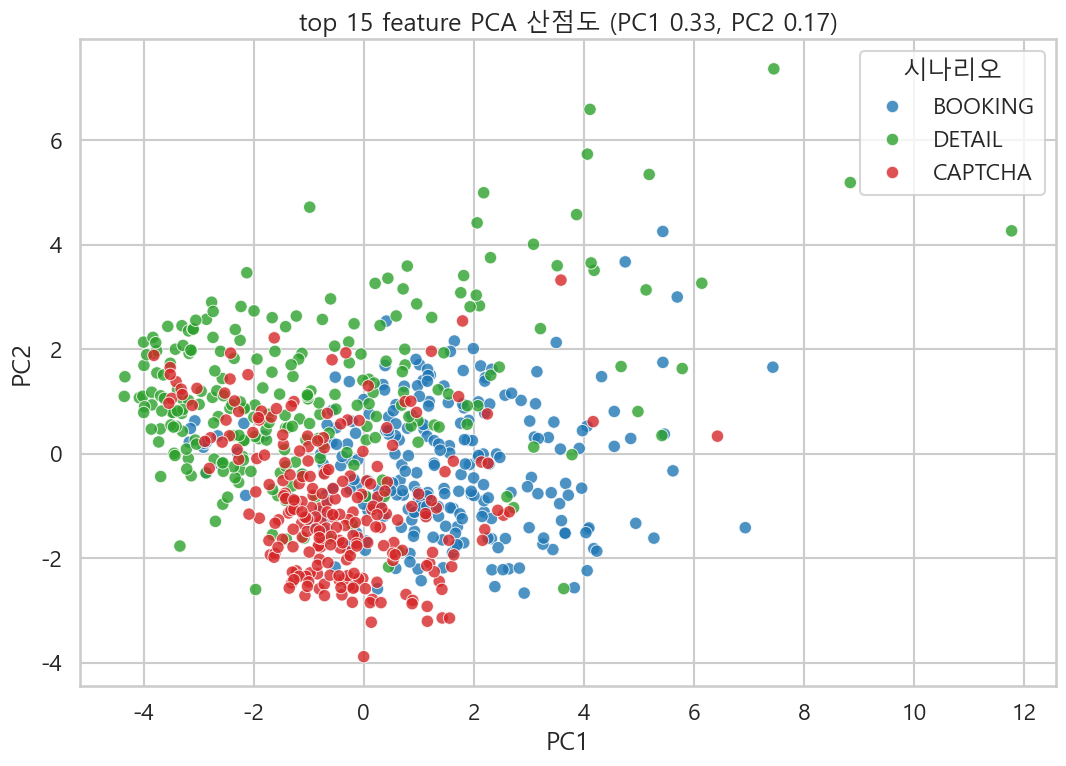

In [18]:
pca_features = feature_rank.head(min(15, len(feature_rank))).index.tolist()
pca_input = analysis_df[pca_features].copy()
pca_input = pca_input.fillna(pca_input.median())  # PCA 입력은 결측 없어야 함

scaled = StandardScaler().fit_transform(pca_input)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(scaled)

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "type": analysis_df["type"].values,
})

explained = pca.explained_variance_ratio_
print("PCA 설명력:")
display(
    pd.DataFrame({
        "성분": ["PC1", "PC2"],
        "설명 분산 비율": explained,
        "누적 설명 분산": np.cumsum(explained),
    })
)

print("\n사용한 feature (max(|SMD|) 상위 15개):")
for f in pca_features:
    print(f"  - {feature_label(f)}")

fig, ax = plt.subplots(figsize=(11, 8))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2",
    hue="type", hue_order=ordered_types,
    palette=TYPE_PALETTE, s=80, alpha=0.8, ax=ax,
)
ax.set_title(
    f"top 15 feature PCA 산점도 (PC1 {explained[0]:.2f}, PC2 {explained[1]:.2f})"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="시나리오")
plt.tight_layout()
plt.show()

## 4. 결과 해석 가이드

- **시나리오 카운트** — `dataset_overview` 로 세 시나리오의 trial 수가 비슷한지 먼저 확인합니다. 차이가 크면 SMD 가 표본 수에 영향을 받을 수 있습니다.
- **결측률** — `null_rate` 히트맵에서 시나리오마다 결측률이 다른 feature 가 있다면, 해당 feature 의 SMD 결과는 신뢰도가 낮으므로 우선순위를 낮춰서 봅니다.
- **Pairwise SMD** — `pairwise_smd` / `feature_rank` 로 어떤 feature 가 세 시나리오를 가장 잘 구분하는지 확인합니다. 같은 feature 라도 비교 쌍마다 |SMD| 가 다를 수 있으므로 §3-1 의 pairwise heatmap 으로 어느 쌍에서 차이가 큰지 같이 확인합니다.
- **박스플롯 + 상관관계** — |SMD| 가 큰 feature 라도 이상치 영향이거나 다른 마우스 feature 와 함께 움직이는 경우가 많습니다. 박스플롯의 분포 형태와 §3-2 의 시나리오별 상관관계를 함께 봐야 해석이 안정적입니다.
- **PCA** — 분리도 시각화 용도일 뿐, 최종 의사결정 기준으로 쓰지 않습니다. 시나리오가 겹친다면 "마우스 행동만으로는 시나리오 차이가 작다" 는 결론도 유의미합니다.

### 후속 작업 제안

- max(|SMD|) 가 `large` 이상인 feature 는 모델 입력 후보 또는 시나리오별 정규화 후보로 검토합니다.
- 100% 결측 feature(예: `click_offset_variance_px`, `mouse_hover_dwell_time_ms` 등 DOM 의존 feature) 는 ALLOW 데이터 수집 파이프라인 차원에서 비어 있는 것으로 알려져 있어, BLOCK(매크로) 데이터와의 비교 분석에서 별도 처리 필요합니다.
- 시나리오별 trial 단위 outlier 분석은 별도 노트북 (예: `eda_h1_v1_allow.ipynb` 의 composite_score 패턴) 에서 다룰 수 있습니다.